### Импорты, сетка, начальные данные и оператор Лапласа (Нейман)

В работе используется минимальный набор инструментов:  
`numpy` — для массивов, `matplotlib` — для графиков, `solve_ivp` из `scipy.integrate` — для интегрирования ОДУ.

**Постановка задачи**

- Область: `x ∈ [0, 1]`  
- Пространственная сетка: `Nx = 201`, шаг `dx = 1 / (Nx - 1)`  
- Начальное условие:

  $$u(x, 0) = \exp(-100(x - 0.5)^2)$$  

  Оно создаёт локальный максимум в центре, что удобно для анализа распространения фронта.

**Дискретизация оператора Лапласа с Неймановскими границами**

Используется трёхточечная аппроксимация второй производной:

$$\frac{u_{i-1} - 2u_i + u_{i+1}}{dx^2}$$  

С модификацией на краях для условий Неймана:

$$\frac{\partial u}{\partial x}(0, t) = \frac{\partial u}{\partial x}(1, t) = 0$$  

Для этого применяются зеркальные точки:
- слева: `u[-1] = u[1]`
- справа: `u[N] = u[N-2]`

Такая матрица имеет нулевую сумму строк (константная функция остаётся решением)  
и является симметричной отрицательно полуопределённой, что гарантирует устойчивость для диффузионного члена.


In [1]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

D_default = 0.01
r_default = 1.0
Lx = 1.0
Nx = 201
x = np.linspace(0.0, Lx, Nx)
dx = x[1] - x[0]

def u0(x):
    return np.exp(-100.0*(x-0.5)**2)
u_init = u0(x)

def neumann_laplacian_matrix(Nx, dx):
    A = np.zeros((Nx, Nx))
    for i in range(1, Nx-1):
        A[i, i-1] = 1.0
        A[i, i]   = -2.0
        A[i, i+1] = 1.0
    A[0, 0] = -2.0
    A[0, 1] = 2.0
    A[-1, -2] = 2.0
    A[-1, -1] = -2.0
    return A / (dx*dx)

L_op = neumann_laplacian_matrix(Nx, dx)

def reaction(u, r):
    return r*u*(1.0 - u)


### Явная схема FTCS (Forward-Time Centered-Space)

Метод решает уравнение вида:

`∂u/∂t = D * ∂²u/∂x² + r * u * (1 - u)`

в явной форме:

`u[n+1] = u[n] + dt * (D * L @ u[n] + r * u[n] * (1 - u[n]))`

где `L` — дискретный оператор второй производной с граничными условиями Неймана.

**Особенности реализации**
- Диффузионный и реакционный члены вычисляются явно на каждом шаге.
- Результаты сохраняются для последующей визуализации.
- Используется `np.clip(u, 0, 1.5)` как защита от численной неустойчивости

**Устойчивость**
- Для чистой диффузии: `dt <= dx² / (2D)`
- При наличии реакции шаг по времени нужно дополнительно уменьшать, примерно до `dt < 1 / r`
- При превышении шага FTCS становится неустойчивой (решение «взрывается»).


In [2]:

def simulate_ftcs(u0, D, r, dt, t_end):
    u = u0.copy()
    t = 0.0
    us = [u.copy()]
    ts = [t]
    A = D * L_op
    while t < t_end - 1e-15:
        du_dt = A.dot(u) + reaction(u, r)
        u = u + dt * du_dt
        u = np.clip(u, 0.0, 1.5)
        t += dt
        us.append(u.copy())
        ts.append(t)
    return np.array(ts), np.stack(us, axis=0)

def ftcs_stability_limit(D):
    return 0.5*dx*dx / D


### Полунеявная схема Кранка–Николсона (IMEX)

Что делает код:
- Диффузия — полунеявно по Кранку–Николсону:
  решается линейная система $(I - 0.5*dt*A) * u_{n+1} = (I + 0.5*dt*A) * u_n + dt * R(u_n)$,
  где $A = D * L_op$, $R(u) = r * u * (1 - u)$.
- Результаты сохраняются в `ts`, `us`.

Плюсы:
- Более устойчиво по диффузии, чем FTCS.
- Линейная система с постоянной матрицей `LHS` при фиксированном `dt` решается быстро.

Замечания:
- Из-за явной реакции общий порядок по времени близок к первому.
- Для точного выхода на `t_end` лучше использовать `dt_eff = min(dt, t_end - t)` и тогда
  пересобрать `LHS = I - 0.5*dt_eff*A`, `RHS_base_mat = I + 0.5*dt_eff*A`.
- Проверка `np.isfinite(u)` полезна для раннего выхода при численных сбоях.


In [3]:

def simulate_crank_nicolson(u0, D, r, dt, t_end):
    u = u0.copy()
    t = 0.0
    us = [u.copy()]
    ts = [t]

    A = D * L_op
    I = np.eye(len(u))
    LHS = I - 0.5*dt*A
    RHS_base_mat = I + 0.5*dt*A

    while t < t_end - 1e-15:
        b = RHS_base_mat.dot(u) + dt * reaction(u, r)
        u = np.linalg.solve(LHS, b)
        u = np.clip(u, 0.0, 1.5)
        t += dt
        us.append(u.copy())
        ts.append(t)
    return np.array(ts), np.stack(us, axis=0)


### Полностью неявная схема (Backward Euler) + Ньютон

Что делает код:
- На шаге по времени решается нелинейное уравнение для `u_{n+1}` методом Ньютона.
- Остаток: `F(u) = u - u_n - dt * (D * L_op @ u + r * u * (1 - u))`.
- Якобиан: `J(u) = I - dt * (D * L_op + diag(r * (1 - 2*u)))`.
- На каждой итерации решаем `J * delta = -F` и обновляем `u <- u + delta`.

Плюсы:
- Устойчива при больших `dt` за счёт полной неявности и учёта нелинейности в итерации.

Замечания по надёжности:
- Критерий остановки лучше делать по двум условиям: норма `F` и норма шага `delta`.
- На последнем шаге времени стоит использовать `dt_eff = min(dt, t_end - t)`.
- Линейный поиск (уменьшение шага `alpha` в `u + alpha * delta`) помогает, если Ньютон делает слишком большой шаг.


In [4]:

def newton_solve_step_BE(u_n, D, r, dt, tol=1e-10, maxit=20):
    u = u_n.copy()
    N = len(u)
    I = np.eye(N)
    DL = D * L_op
    for k in range(maxit):
        f_reac = r*u*(1.0 - u)
        F = u - u_n - dt*(DL.dot(u) + f_reac)
        if np.linalg.norm(F, np.inf) < tol:
            return u, k
        diag = r*(1.0 - 2.0*u)
        J = I - dt*(DL + np.diag(diag))
        delta = np.linalg.solve(J, -F)
        u = u + delta
        if np.max(np.abs(delta)) > 1.0:
            u = np.clip(u, -0.5, 2.0)
    return u, maxit

def simulate_implicit_newton(u0, D, r, dt, t_end, tol=1e-10, maxit=20):
    u = u0.copy()
    t = 0.0
    us = [u.copy()]
    ts = [t]
    iters = []
    while t < t_end - 1e-15:
        u_new, k = newton_solve_step_BE(u, D, r, dt, tol=tol, maxit=maxit)
        u = np.clip(u_new, 0.0, 1.5)
        t += dt
        us.append(u.copy())
        ts.append(t)
        iters.append(k)
    return np.array(ts), np.stack(us, axis=0), np.array(iters)


### Метод линий (Method of Lines, MOL)

Идея:
- Сначала дискретизируем пространство (оператор `L_op`), оставляя время непрерывным.
- Получаем систему ОДУ:
  `du/dt = D * (L_op @ u) + r * u * (1 - u)`
- Далее решаем эту систему стандартным интегратором `solve_ivp` (метод Рунге–Кутты 4/5 порядка).

Параметры функции:
- `u0` — начальное распределение;
- `t_span = (t0, t_end)` — диапазон времени;
- `t_eval` — сетка, где нужны результаты;
- `rtol`, `atol` — относительная и абсолютная точность интегратора.

Особенности реализации:
- `rhs_mol` возвращает правую часть системы для текущего состояния `u`.

Результат:
- `sol.t` — вектор времени;
- `sol.y.T` — двумерный массив решений (времена × узлы).


In [5]:

def rhs_mol(t, u, D, r):
    return D * (L_op @ u) + r*u*(1.0 - u)

def simulate_mol(u0, D, r, t_span, t_eval=None, rtol=1e-7, atol=1e-9):
    fun = lambda t, y: rhs_mol(t, y, D, r)
    sol = solve_ivp(fun, t_span, u0, method='RK45', t_eval=t_eval, rtol=rtol, atol=atol, vectorized=False)
    return sol.t, sol.y.T


### Сравнение схем: FTCS, Crank–Nicolson, BE+Newton против MOL (эталон)

Что делает код:
- Запускает три численных схемы: `simulate_ftcs`, `simulate_crank_nicolson`, `simulate_implicit_newton`.
- Строит эталон через метод линий: `simulate_mol(..., method='RK45')` на сетке `t_eval`.
- Пересчитывает решения на общую временную сетку для сравнения (в коде — ближайший сосед).
- Считает метрику ошибки: `max |u_method - u_MOL|` по всей сетке `(t, x)`.
- Рисует профили `u(x, t_end)` для всех методов и эталона.

FTCS dt= 0.0001  max|err| vs MOL: 0.0001973596144159151
CN   dt= 0.001  max|err| vs MOL: 4.5542903843509563e-05
BE+Newton dt= 0.01  max|err| vs MOL: 0.016559015024374513
Newton iterations per step stats: min 2, max 2, mean 2.00


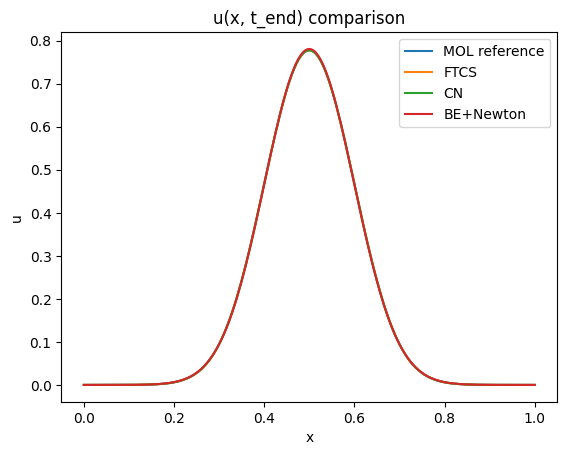

In [6]:

def run_all_basic(dt_ftcs=1e-4, dt_cn=1e-3, dt_imp=1e-2, t_end=0.2, D=D_default, r=r_default):
    ts_ftcs, us_ftcs = simulate_ftcs(u_init, D, r, dt_ftcs, t_end)
    ts_cn,   us_cn   = simulate_crank_nicolson(u_init, D, r, dt_cn, t_end)
    ts_imp,  us_imp, iters = simulate_implicit_newton(u_init, D, r, dt_imp, t_end)
    t_eval = np.linspace(0.0, t_end, 201)
    ts_mol, us_mol = simulate_mol(u_init, D, r, (0.0, t_end), t_eval=t_eval)

    def interp_to_ref(ts, us, tref):
        idxs = np.searchsorted(ts, tref, side='left')
        idxs = np.clip(idxs, 0, len(ts)-1)
        return us[idxs]

    us_ftcs_ref = interp_to_ref(ts_ftcs, us_ftcs, ts_mol)
    us_cn_ref   = interp_to_ref(ts_cn,   us_cn,   ts_mol)
    us_imp_ref  = interp_to_ref(ts_imp,  us_imp,  ts_mol)

    err_ftcs = np.max(np.abs(us_ftcs_ref - us_mol))
    err_cn   = np.max(np.abs(us_cn_ref   - us_mol))
    err_imp  = np.max(np.abs(us_imp_ref  - us_mol))

    print("FTCS dt=", dt_ftcs, " max|err| vs MOL:", err_ftcs)
    print("CN   dt=", dt_cn,   " max|err| vs MOL:", err_cn)
    print("BE+Newton dt=", dt_imp, " max|err| vs MOL:", err_imp)
    print("Newton iterations per step stats: min {}, max {}, mean {:.2f}".format(iters.min(), iters.max(), iters.mean()))

    plt.figure()
    plt.plot(x, us_mol[-1], label="MOL reference")
    plt.plot(x, us_ftcs_ref[-1], label="FTCS")
    plt.plot(x, us_cn_ref[-1], label="CN")
    plt.plot(x, us_imp_ref[-1], label="BE+Newton")
    plt.legend()
    plt.title("u(x, t_end) comparison")
    plt.xlabel("x")
    plt.ylabel("u")
    plt.show()

run_all_basic()


### Демонстрация неустойчивости схемы FTCS

На рисунке показан эксперимент по проверке устойчивости явной схемы FTCS при разных шагах по времени `dt`.

**Параметры:**
- `D = 0.01`, `r = 2.0`
- `dx = 0.005`, значит теоретический предел устойчивости:  
  `dt_limit = dx² / (2D) ≈ 0.00125`
- Рассматривались шаги:  
  `dt = [0.0005, 0.001, 0.0013, 0.0016, 0.002]`

**Наблюдения:**
- Для `dt ≤ 0.001` решение устойчиво: максимум `|u|` не растёт, профиль остаётся гладким.  
- При `dt > 0.00125` начинаются осцилляции и рост амплитуды — явный признак потери устойчивости.  
- На графике `max|u|(t)` видно экспоненциальный рост после прохождения критического шага.

dx=0.00500  diff_limit≈0.001250  react_limit≈0.500000  min≈0.001250
dt=0.0005   ok=True  t_last=0.8000  max|u|=1
dt=0.001    ok=True  t_last=0.8000  max|u|=1
dt=0.0013   ok=False  t_last=0.5551  max|u|=4.75
dt=0.0016   ok=False  t_last=0.1104  max|u|=3.31
dt=0.002    ok=False  t_last=0.0760  max|u|=2.49


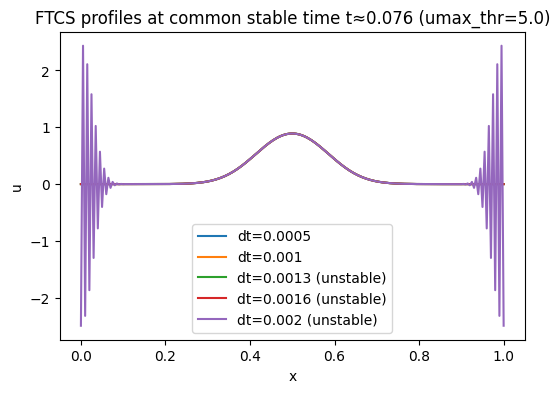

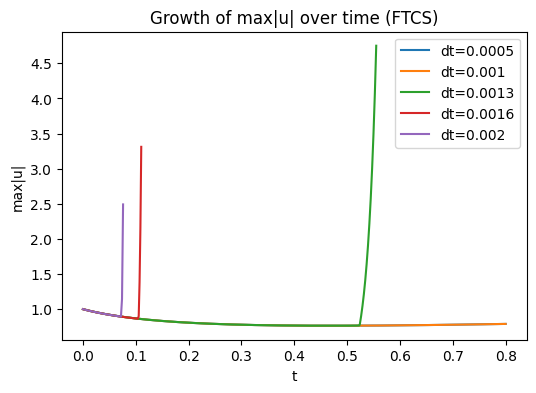

In [7]:
def simulate_ftcs_monitor(u0, D, r, dt, t_end, umax_thr=5.0):
    u = u0.copy()
    t = 0.0
    A = D * L_op
    ts = [t]
    us = [u.copy()]
    while t < t_end - 1e-15:
        dt_eff = dt if t + dt <= t_end else (t_end - t)
        du_dt = A.dot(u) + r * u * (1.0 - u)
        u_next = u + dt_eff * du_dt
        if not np.all(np.isfinite(u_next)) or np.max(np.abs(u_next)) > umax_thr:
            return np.array(ts), np.stack(us, axis=0), False
        u = u_next
        t += dt_eff
        ts.append(t); us.append(u.copy())
    return np.array(ts), np.stack(us, axis=0), True

def interp_time_linear(ts, us, t_plot):
    import numpy as np
    if t_plot <= ts[0]: return us[0]
    if t_plot >= ts[-1]: return us[-1]
    j = np.searchsorted(ts, t_plot)
    t0, t1 = ts[j-1], ts[j]
    w = (t_plot - t0) / (t1 - t0 + 1e-300)
    return (1.0 - w) * us[j-1] + w * us[j]

def ftcs_demo_readable(D=0.01, r=2.0, t_end=0.8,
                       dts=(5e-4, 1e-3, 1.3e-3, 1.6e-3, 2e-3),
                       umax_thr=5.0):
    lim = dx*dx/(2*D)
    print(f"dx={dx:.5f}  diff_limit≈{lim:.6f}  react_limit≈{1/r:.6f}  min≈{min(lim,1/r):.6f}")
    runs = []
    t_plot = t_end
    for dt in dts:
        ts, us, ok = simulate_ftcs_monitor(u_init, D, r, dt, t_end, umax_thr=umax_thr)
        t_last = ts[-1]
        t_plot = min(t_plot, t_last)
        runs.append((dt, ts, us, ok, t_last, np.max(us)))
        print(f"dt={dt:<8} ok={ok}  t_last={t_last:.4f}  max|u|={np.max(np.abs(us)):.3g}")
    if t_plot <= 0.0:
        t_plot = max(r[1][-1] for r in runs) * 0.5

    plt.figure(figsize=(6,4))
    for dt, ts, us, ok, t_last, _ in runs:
        u_plot = interp_time_linear(ts, us, t_plot)
        lbl = f"dt={dt}" + ("" if ok and t_last>=t_end-1e-12 else " (unstable)")
        plt.plot(x, u_plot, label=lbl)
    plt.xlabel("x"); plt.ylabel("u")
    plt.title(f"FTCS profiles at common stable time t≈{t_plot:.3f} (umax_thr={umax_thr})")
    plt.legend(); plt.show()

    plt.figure(figsize=(6,4))
    for dt, ts, us, ok, t_last, _ in runs:
        plt.plot(ts, np.max(np.abs(us), axis=1), label=f"dt={dt}")
    plt.xlabel("t"); plt.ylabel("max|u|")
    plt.title("Growth of max|u| over time (FTCS)")
    plt.legend(); plt.show()


ftcs_demo_readable(D=0.01, r=2.0, t_end=0.8,
                   dts=(5e-4, 1e-3, 1.3e-3, 1.6e-3, 2e-3),
                   umax_thr=5.0)


### Семейство решений: статические профили + анимация без ползунков

Что делает код:
- Предвычисляет решения `u(x,t)` для набора параметров `(D, r)` на общей сетке `t_eval`.
- Рисует **один статический график**: все финальные профили `u(x, t_end)` на одном полотне.
- Создаёт **анимацию без интерфейсных контролов**: по кадрам проходит время и перебираются пары `(D, r)`.


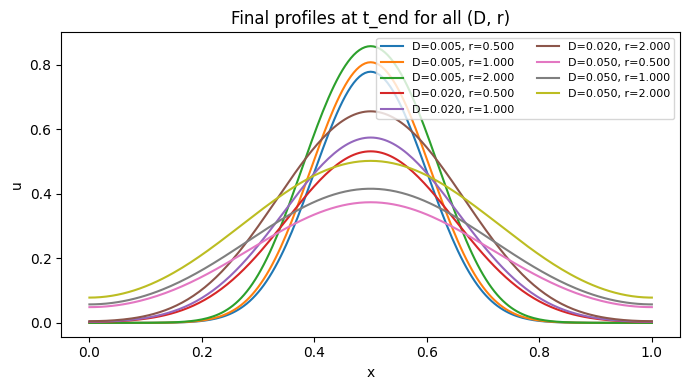

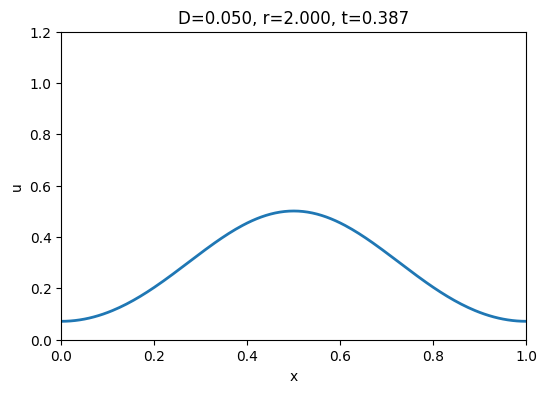

In [8]:
# Анимация БЕЗ ползунков + один статический график со всеми финальными профилями

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Параметры
D_vals = [0.005, 0.02, 0.05]        # можно расширить
r_vals = [0.5, 1.0, 2.0]
t_end  = 0.4
n_time = 120
frame_skip = 5                      # показываем каждый 5-й кадр
rtol, atol = 1e-6, 1e-8

# Предсчёт траекторий для всех (D, r)
pairs = [(D, r) for D in D_vals for r in r_vals]
t_eval = np.linspace(0.0, t_end, n_time)
pre = []
for D, r in pairs:
    ts, us = simulate_mol(u_init, D, r, (0, t_end), t_eval=t_eval, rtol=rtol, atol=atol)
    pre.append((D, r, ts, us))

# 1) Статический рисунок: все финальные профили на одном графике
plt.figure(figsize=(7,4))
for (D, r, ts, us) in pre:
    plt.plot(x, us[-1], label=f"D={D:.3f}, r={r:.3f}")
plt.xlabel("x"); plt.ylabel("u")
plt.title("Final profiles at t_end for all (D, r)")
plt.legend(ncols=2, fontsize=8)
plt.tight_layout()
plt.show()

# 2) Анимация без ползунков: по времени и по всем парам параметров
fig, ax = plt.subplots(figsize=(6,4))
(line,) = ax.plot([], [], lw=2)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.2)
ax.set_xlabel("x"); ax.set_ylabel("u")

total_frames = len(pre) * len(t_eval)
frames = np.arange(0, total_frames, frame_skip)  # пропуск кадров

def init():
    line.set_data([], [])
    ax.set_title("Preparing...")
    return (line,)

def update(k):
    idx_pair = (k // len(t_eval)) % len(pre)
    idx_t    =  (k %  len(t_eval))
    D, r, ts, us = pre[idx_pair]
    line.set_data(x, us[idx_t])
    ax.set_title(f"D={D:.3f}, r={r:.3f}, t={ts[idx_t]:.3f}")
    return (line,)

ani = FuncAnimation(fig, update, frames=frames, init_func=init, blit=True, interval=40, repeat=True)

# В Colab быстрее HTML5-видео, без интерактивных контролов-слайдеров
HTML(ani.to_html5_video())


### Точность схем по шагу времени: CN vs BE+Newton

Назначение:
- Построить зависимость ошибки от шага `dt` для двух методов:
  - **CN (полунеявная)**: диффузия — Кранк–Николсон, реакция — явная.
  - **BE+Newton (полностью неявная)**: шаг назад по времени + Ньютон.
- Эталон — метод линий (`solve_ivp` RK45) с жёсткими `rtol=1e-9`, `atol=1e-11` на сетке `t_eval`.

Как считается ошибка:
- Для каждого `dt` интегрируем метод и **переносим** решение на сетку эталона.
- В коде используется `nearest`-интерполяция по времени (быстро, но даёт верхнюю оценку ошибки).
- Метрика: `max abs error vs MOL` по всем `(t, x)`.

Что показывают графики:
- `Accuracy vs dt` (лог–лог): убывание ошибки при уменьшении `dt`.
  - Для **CN** порядок обычно ~1 из-за явной реакции.
  - Для **BE+Newton** также порядок ~1 по времени, но стабильность лучше при крупных `dt`.
- `Newton iterations vs dt`: среднее число итераций Ньютона на шаг.
  - При меньших `dt` шаг ближе к линейному → итераций меньше.
  - При больших `dt` нелинейность сильнее → итераций больше.


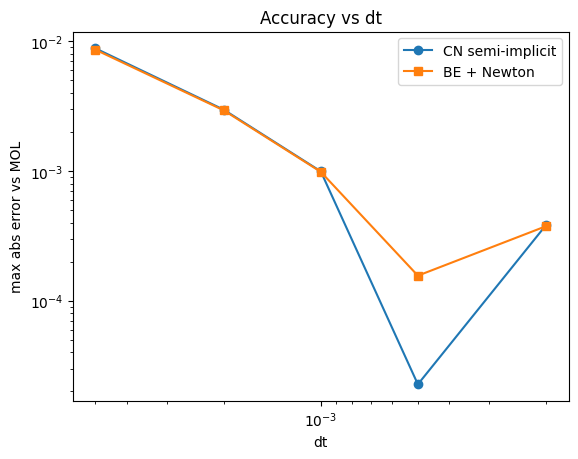

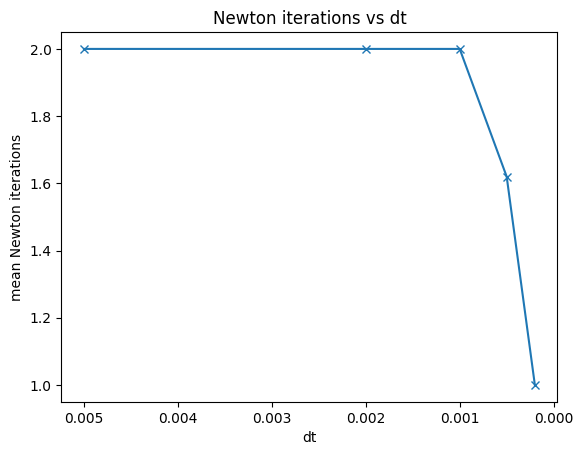

In [9]:

def accuracy_vs_dt(D=D_default, r=r_default, t_end=0.2, dts=[5e-3, 2e-3, 1e-3, 5e-4, 2e-4]):
    # reference via MOL fine
    t_eval = np.linspace(0.0, t_end, 401)
    ts_ref, us_ref = simulate_mol(u_init, D, r, (0.0, t_end), t_eval=t_eval, rtol=1e-9, atol=1e-11)

    errs_cn = []
    errs_imp = []
    iters_imp = []
    for dt in dts:
        ts_cn, us_cn = simulate_crank_nicolson(u_init, D, r, dt, t_end)
        # interpolate CN to reference grid (nearest)
        idxs = np.searchsorted(ts_cn, ts_ref, side='left')
        idxs = np.clip(idxs, 0, len(ts_cn)-1)
        err_cn = np.max(np.abs(us_cn[idxs]-us_ref))
        errs_cn.append(err_cn)

        ts_imp, us_imp, iters = simulate_implicit_newton(u_init, D, r, dt, t_end)
        idxs2 = np.searchsorted(ts_imp, ts_ref, side='left')
        idxs2 = np.clip(idxs2, 0, len(ts_imp)-1)
        err_imp = np.max(np.abs(us_imp[idxs2]-us_ref))
        errs_imp.append(err_imp)
        iters_imp.append(np.mean(iters))

    plt.figure()
    plt.loglog(dts, errs_cn, marker='o', label='CN semi-implicit')
    plt.loglog(dts, errs_imp, marker='s', label='BE + Newton')
    plt.gca().invert_xaxis()
    plt.xlabel('dt')
    plt.ylabel('max abs error vs MOL')
    plt.legend()
    plt.title('Accuracy vs dt')
    plt.show()

    plt.figure()
    plt.plot(dts, iters_imp, marker='x')
    plt.gca().invert_xaxis()
    plt.xlabel('dt')
    plt.ylabel('mean Newton iterations')
    plt.title('Newton iterations vs dt')
    plt.show()

# Example
accuracy_vs_dt()


### Эволюция решения во времени (Crank–Nicolson)

Как работает пример:
- Решение строится методом **Кранка–Николсона** с шагом `dt = 5e-4` до момента `t_end = 0.2`.
- Далее выбираются равномерные по времени индексы и рисуются профили `u(x, t)` на одном графике.

Интерпретация:
- Кривые показывают, как волна (или популяционный фронт) плавно растекается во времени.
- При симметричных начальных условиях максимум остаётся в центре.
- Диффузия постепенно сглаживает профиль, а реакционный член ускоряет рост в областях с малым `u`.

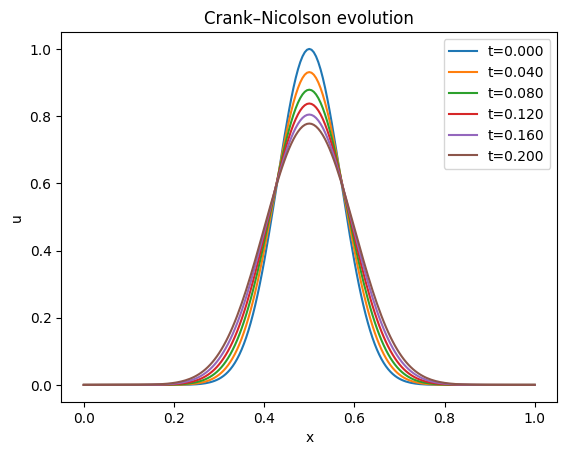

In [10]:

def plot_time_slice(ts, us, n=5, title=""):
    idxs = np.linspace(0, len(ts)-1, n, dtype=int)
    plt.figure()
    for i in idxs:
        plt.plot(x, us[i], label=f"t={ts[i]:.3f}")
    plt.legend()
    if title:
        plt.title(title)
    plt.xlabel("x"); plt.ylabel("u")
    plt.show()

# Example single method preview
ts, us = simulate_crank_nicolson(u_init, D_default, r_default, 5e-4, 0.2)
plot_time_slice(ts, us, n=6, title="Crank–Nicolson evolution")
